# SIFT Part 2: Keypoint Localization

## The Problem

In Notebook 01, we found **candidate keypoints** by detecting extrema in the DoG pyramid. But these have issues:

1. **Pixel-level accuracy only**: Real features are between pixels
2. **Edge responses**: Edges are detected but make poor keypoints (not repeatable)
3. **Low contrast points**: Noisy, unstable across images

This notebook shows how SIFT **refines and filters** keypoints to keep only the best ones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Copy functions from Notebook 01
def gaussian_kernel_1d(sigma, size=None):
    if size is None:
        size = int(np.ceil(6 * sigma))
        if size % 2 == 0:
            size += 1
    x = np.arange(size) - size // 2
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / kernel.sum()

def gaussian_blur(image, sigma):
    kernel = gaussian_kernel_1d(sigma)
    pad = len(kernel) // 2
    padded = np.pad(image, pad, mode='reflect')
    temp = np.zeros_like(padded, dtype=np.float64)
    for i in range(len(kernel)):
        temp[:, pad:-pad] += kernel[i] * padded[:, i:i+image.shape[1]]
    result = np.zeros_like(image, dtype=np.float64)
    for i in range(len(kernel)):
        result += kernel[i] * temp[i:i+image.shape[0], pad:-pad]
    return result

def build_gaussian_pyramid(image, num_octaves=4, num_scales=5, sigma_base=1.6):
    s = num_scales - 3
    k = 2 ** (1 / s)
    pyramid = []
    sigmas_per_octave = []
    sigma_values = [sigma_base * (k ** i) for i in range(num_scales)]
    current_image = image.astype(np.float64)
    
    for octave in range(num_octaves):
        octave_images = []
        octave_sigmas = []
        for scale_idx, sigma in enumerate(sigma_values):
            if scale_idx == 0:
                blurred = gaussian_blur(current_image, sigma)
            else:
                sigma_prev = sigma_values[scale_idx - 1]
                sigma_diff = np.sqrt(sigma**2 - sigma_prev**2)
                blurred = gaussian_blur(octave_images[-1], sigma_diff)
            octave_images.append(blurred)
            octave_sigmas.append(sigma * (2 ** octave))
        pyramid.append(octave_images)
        sigmas_per_octave.append(octave_sigmas)
        if octave < num_octaves - 1:
            current_image = octave_images[s][::2, ::2]
    return pyramid, sigmas_per_octave

def build_dog_pyramid(gaussian_pyramid):
    dog_pyramid = []
    for octave_images in gaussian_pyramid:
        dog_octave = []
        for i in range(len(octave_images) - 1):
            dog = octave_images[i + 1] - octave_images[i]
            dog_octave.append(dog)
        dog_pyramid.append(dog_octave)
    return dog_pyramid

In [2]:
# Load test image
examples_path = Path('../../Examples')
test_images = list(examples_path.glob('*.jpg')) + list(examples_path.glob('*.png'))

if test_images:
    img = cv2.imread(str(test_images[0]), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (400, 400))
else:
    img = np.ones((400, 400), dtype=np.uint8) * 255
    for i in range(0, 401, 44):
        img[i:i+2, :] = 0
        img[:, i:i+2] = 0

img_normalized = img.astype(np.float64) / 255.0

# Build pyramids
pyramid, sigmas = build_gaussian_pyramid(img_normalized, num_octaves=4, num_scales=5)
dog_pyramid = build_dog_pyramid(pyramid)

print(f"Image: {img.shape}")
print(f"DoG pyramid: {len(dog_pyramid)} octaves")

Image: (400, 400)
DoG pyramid: 4 octaves


## 1. Sub-Pixel Localization via Taylor Expansion

### The Problem with Pixel-Level Detection

Our extrema detection finds the best **integer pixel** location. But the true extremum is usually **between pixels**:

```
     DoG values:  [0.12]  [0.18]  [0.15]
     Pixel:         x-1      x      x+1
                            ↑
                    Detected (but true peak is at x-0.3)
```

### Solution: Fit a Quadratic and Find Its Peak

We use a **Taylor expansion** around the detected point:

$$D(\mathbf{x}) \approx D + \frac{\partial D}{\partial \mathbf{x}}^T \mathbf{x} + \frac{1}{2} \mathbf{x}^T \frac{\partial^2 D}{\partial \mathbf{x}^2} \mathbf{x}$$

Where:
- $D$ = DoG value at detected point
- $\mathbf{x} = (x, y, \sigma)$ = offset from detected point
- First derivatives = gradient
- Second derivatives = Hessian matrix

Setting derivative to zero and solving:

$$\hat{\mathbf{x}} = -\frac{\partial^2 D}{\partial \mathbf{x}^2}^{-1} \frac{\partial D}{\partial \mathbf{x}}$$

In [3]:
def compute_gradient_3d(dog_octave, scale, y, x):
    """
    Compute the gradient of DoG at (scale, y, x) using central differences.
    
    Returns: [dD/dx, dD/dy, dD/ds] (3D gradient vector)
    """
    # Central difference: f'(x) ≈ (f(x+1) - f(x-1)) / 2
    dx = (dog_octave[scale][y, x + 1] - dog_octave[scale][y, x - 1]) / 2
    dy = (dog_octave[scale][y + 1, x] - dog_octave[scale][y - 1, x]) / 2
    ds = (dog_octave[scale + 1][y, x] - dog_octave[scale - 1][y, x]) / 2
    
    return np.array([dx, dy, ds])


def compute_hessian_3d(dog_octave, scale, y, x):
    """
    Compute the 3x3 Hessian matrix of DoG at (scale, y, x).
    
    The Hessian contains second derivatives:
    H = [[dxx, dxy, dxs],
         [dxy, dyy, dys],
         [dxs, dys, dss]]
    """
    val = dog_octave[scale][y, x]
    
    # Second derivatives: f''(x) ≈ f(x+1) - 2*f(x) + f(x-1)
    dxx = dog_octave[scale][y, x + 1] - 2 * val + dog_octave[scale][y, x - 1]
    dyy = dog_octave[scale][y + 1, x] - 2 * val + dog_octave[scale][y - 1, x]
    dss = dog_octave[scale + 1][y, x] - 2 * val + dog_octave[scale - 1][y, x]
    
    # Cross derivatives: f_xy ≈ (f(x+1,y+1) - f(x+1,y-1) - f(x-1,y+1) + f(x-1,y-1)) / 4
    dxy = (dog_octave[scale][y + 1, x + 1] - dog_octave[scale][y + 1, x - 1] -
           dog_octave[scale][y - 1, x + 1] + dog_octave[scale][y - 1, x - 1]) / 4
    
    dxs = (dog_octave[scale + 1][y, x + 1] - dog_octave[scale + 1][y, x - 1] -
           dog_octave[scale - 1][y, x + 1] + dog_octave[scale - 1][y, x - 1]) / 4
    
    dys = (dog_octave[scale + 1][y + 1, x] - dog_octave[scale + 1][y - 1, x] -
           dog_octave[scale - 1][y + 1, x] + dog_octave[scale - 1][y - 1, x]) / 4
    
    hessian = np.array([
        [dxx, dxy, dxs],
        [dxy, dyy, dys],
        [dxs, dys, dss]
    ])
    
    return hessian

In [4]:
def localize_keypoint(dog_octave, scale, y, x, max_iterations=5):
    """
    Refine keypoint location to sub-pixel accuracy.
    
    Uses iterative Taylor expansion fitting.
    
    Returns:
        (refined_x, refined_y, refined_scale, response) or None if rejected
    """
    height, width = dog_octave[0].shape
    num_scales = len(dog_octave)
    
    for iteration in range(max_iterations):
        # Compute gradient and Hessian
        gradient = compute_gradient_3d(dog_octave, scale, y, x)
        hessian = compute_hessian_3d(dog_octave, scale, y, x)
        
        # Solve for offset: offset = -H^(-1) * g
        try:
            offset = -np.linalg.solve(hessian, gradient)
        except np.linalg.LinAlgError:
            # Singular matrix - reject this keypoint
            return None
        
        # If offset is small, we've converged
        if np.all(np.abs(offset) < 0.5):
            break
        
        # Otherwise, move to new integer location and repeat
        x += int(round(offset[0]))
        y += int(round(offset[1]))
        scale += int(round(offset[2]))
        
        # Check bounds
        if (x < 1 or x >= width - 1 or
            y < 1 or y >= height - 1 or
            scale < 1 or scale >= num_scales - 1):
            return None
    
    # Compute response at refined location
    # D(x_hat) = D + 0.5 * gradient^T * offset
    response = dog_octave[scale][y, x] + 0.5 * np.dot(gradient, offset)
    
    return {
        'x': x + offset[0],
        'y': y + offset[1],
        'scale': scale + offset[2],
        'response': response,
        'offset': offset
    }

In [5]:
# Demonstrate sub-pixel localization on a single point
# Find a candidate keypoint first
octave_idx = 0
scale_idx = 1
dog_octave = dog_pyramid[octave_idx]

# Find a local maximum
test_region = dog_octave[scale_idx][50:100, 50:100]
local_max_idx = np.unravel_index(np.argmax(np.abs(test_region)), test_region.shape)
test_y, test_x = local_max_idx[0] + 50, local_max_idx[1] + 50

print(f"Testing keypoint at pixel ({test_x}, {test_y}), scale {scale_idx}")
print(f"DoG value at pixel: {dog_octave[scale_idx][test_y, test_x]:.6f}")

# Localize
result = localize_keypoint(dog_octave, scale_idx, test_y, test_x)

if result:
    print(f"\nRefined location:")
    print(f"  x: {test_x} → {result['x']:.3f} (offset: {result['offset'][0]:+.3f})")
    print(f"  y: {test_y} → {result['y']:.3f} (offset: {result['offset'][1]:+.3f})")
    print(f"  scale: {scale_idx} → {result['scale']:.3f} (offset: {result['offset'][2]:+.3f})")
    print(f"  Refined response: {result['response']:.6f}")
else:
    print("Keypoint rejected during localization")

Testing keypoint at pixel (88, 89), scale 1
DoG value at pixel: 0.131646
Keypoint rejected during localization


## 2. Removing Low-Contrast Keypoints

### The Problem

Keypoints with low DoG response are:
- Sensitive to noise
- Not stable across different images
- Not reliably detected

### Solution

Reject keypoints where $|D(\hat{\mathbf{x}})| < $ threshold (Lowe uses 0.03).

The refined response we computed above is exactly $D(\hat{\mathbf{x}})$.

In [6]:
def filter_low_contrast(keypoint, contrast_threshold=0.03):
    """
    Check if keypoint has sufficient contrast.
    
    Args:
        keypoint: Result from localize_keypoint()
        contrast_threshold: Minimum |response| to keep
    
    Returns:
        True if keypoint should be KEPT, False if rejected
    """
    return abs(keypoint['response']) >= contrast_threshold

## 3. Removing Edge Responses

### The Problem

DoG responds strongly to **edges**, not just corners/blobs:

```
    Corner (good)          Edge (bad)
    ┌────                  ──────────
    │                      
    │                      
    
    Distinctive in         Only distinctive
    both directions        in one direction
```

Edge points are:
- Poorly localized along the edge
- Sensitive to noise
- Not distinctive enough for matching

### Solution: Check the Hessian Eigenvalues

For a 2D point, the **Hessian eigenvalues** tell us the curvature:
- **Corner**: Both eigenvalues large and similar
- **Edge**: One eigenvalue large, one small
- **Flat**: Both eigenvalues small

### The Efficient Test

Computing eigenvalues is expensive. Instead, use this ratio test:

$$\frac{\text{Tr}(H)^2}{\text{Det}(H)} < \frac{(r+1)^2}{r}$$

Where:
- $H$ = 2x2 Hessian (just x,y, not scale)
- $r$ = ratio threshold (Lowe uses r=10)
- $\text{Tr}(H) = \lambda_1 + \lambda_2$ (trace = sum of eigenvalues)
- $\text{Det}(H) = \lambda_1 \cdot \lambda_2$ (determinant = product)

### Why This Works

If $\lambda_1 = r \cdot \lambda_2$ (one eigenvalue r times bigger):

$$\frac{(\lambda_1 + \lambda_2)^2}{\lambda_1 \cdot \lambda_2} = \frac{(r+1)^2 \lambda_2^2}{r \cdot \lambda_2^2} = \frac{(r+1)^2}{r}$$

So the test rejects if eigenvalue ratio exceeds r.

In [7]:
def compute_hessian_2d(dog_image, y, x):
    """
    Compute the 2x2 spatial Hessian at (y, x).
    
    Returns 2x2 matrix [[dxx, dxy], [dxy, dyy]]
    """
    val = dog_image[y, x]
    
    dxx = dog_image[y, x + 1] - 2 * val + dog_image[y, x - 1]
    dyy = dog_image[y + 1, x] - 2 * val + dog_image[y - 1, x]
    dxy = (dog_image[y + 1, x + 1] - dog_image[y + 1, x - 1] -
           dog_image[y - 1, x + 1] + dog_image[y - 1, x - 1]) / 4
    
    return np.array([[dxx, dxy], [dxy, dyy]])


def filter_edge_response(dog_image, y, x, edge_threshold=10):
    """
    Check if keypoint is on an edge (reject) or corner (keep).
    
    Args:
        dog_image: DoG image at the keypoint's scale
        y, x: Integer keypoint location
        edge_threshold: Maximum allowed eigenvalue ratio (r in paper)
    
    Returns:
        True if keypoint should be KEPT (corner-like)
        False if keypoint should be rejected (edge-like)
    """
    H = compute_hessian_2d(dog_image, y, x)
    
    trace = H[0, 0] + H[1, 1]
    det = H[0, 0] * H[1, 1] - H[0, 1] * H[1, 0]
    
    # Reject if determinant is negative (saddle point)
    if det <= 0:
        return False
    
    # The ratio test
    r = edge_threshold
    threshold = ((r + 1) ** 2) / r
    
    ratio = (trace ** 2) / det
    
    return ratio < threshold

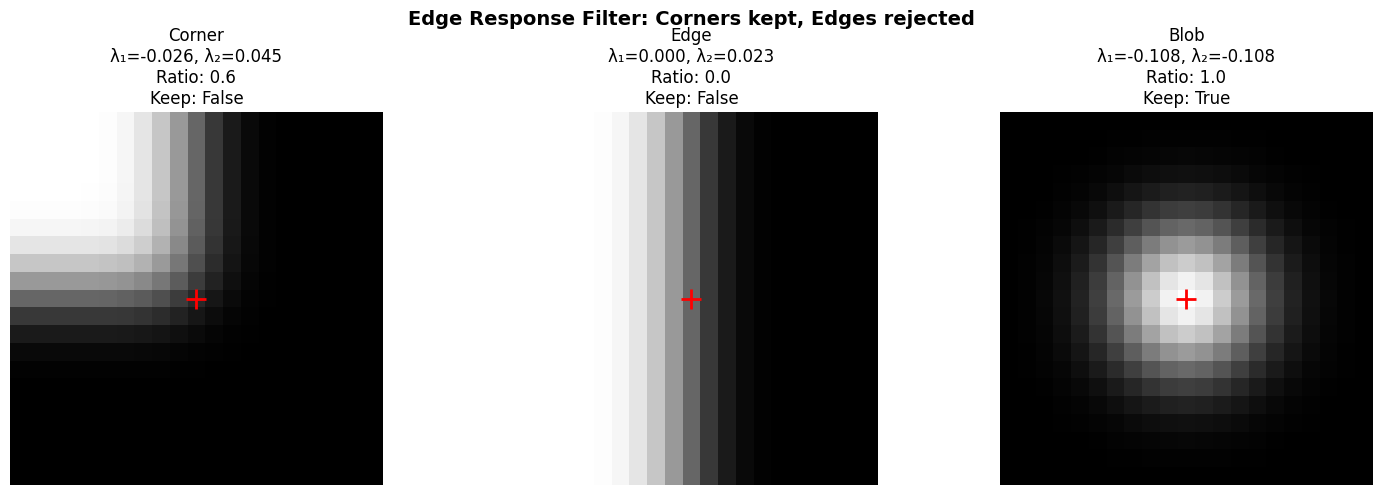

In [8]:
# Visualize the edge vs corner detection
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Create synthetic examples
size = 21
center = size // 2

# Corner-like pattern
corner = np.zeros((size, size))
corner[:center, :center] = 1
corner = gaussian_blur(corner, 2)

# Edge-like pattern
edge = np.zeros((size, size))
edge[:, :center] = 1
edge = gaussian_blur(edge, 2)

# Blob-like pattern
blob = np.zeros((size, size))
y, x = np.ogrid[:size, :size]
blob = np.exp(-((x - center)**2 + (y - center)**2) / (2 * 3**2))

patterns = [corner, edge, blob]
names = ['Corner', 'Edge', 'Blob']

for ax, pattern, name in zip(axes, patterns, names):
    ax.imshow(pattern, cmap='gray')
    
    # Compute Hessian and eigenvalues
    H = compute_hessian_2d(pattern, center, center)
    eigenvalues = np.linalg.eigvalsh(H)
    
    trace = H[0, 0] + H[1, 1]
    det = H[0, 0] * H[1, 1] - H[0, 1] ** 2
    
    is_corner = filter_edge_response(pattern, center, center)
    
    ax.set_title(f'{name}\nλ₁={eigenvalues[0]:.3f}, λ₂={eigenvalues[1]:.3f}\n'
                 f'Ratio: {abs(eigenvalues[0]/eigenvalues[1]) if eigenvalues[1] != 0 else np.inf:.1f}\n'
                 f'Keep: {is_corner}')
    ax.plot(center, center, 'r+', markersize=15, markeredgewidth=2)
    ax.axis('off')

plt.suptitle('Edge Response Filter: Corners kept, Edges rejected', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Complete Keypoint Detection Pipeline

Now let's put it all together:

In [9]:
def find_keypoints(dog_pyramid, sigmas, 
                   contrast_threshold=0.03, 
                   edge_threshold=10,
                   initial_threshold=0.01):
    """
    Complete SIFT keypoint detection with localization and filtering.
    
    Steps:
    1. Find DoG extrema (candidate keypoints)
    2. Localize to sub-pixel accuracy
    3. Filter low-contrast points
    4. Filter edge responses
    
    Returns:
        List of keypoints with (x, y, octave, scale, sigma, response)
    """
    keypoints = []
    stats = {'candidates': 0, 'localization_failed': 0, 
             'low_contrast': 0, 'edge_response': 0, 'accepted': 0}
    
    for octave_idx, dog_octave in enumerate(dog_pyramid):
        if len(dog_octave) < 3:
            continue
        
        height, width = dog_octave[0].shape
        
        # Check each scale (excluding first and last)
        for scale_idx in range(1, len(dog_octave) - 1):
            current = dog_octave[scale_idx]
            below = dog_octave[scale_idx - 1]
            above = dog_octave[scale_idx + 1]
            
            # Check each pixel (excluding border)
            for y in range(1, height - 1):
                for x in range(1, width - 1):
                    val = current[y, x]
                    
                    # Initial threshold check
                    if abs(val) < initial_threshold:
                        continue
                    
                    # Check if extremum
                    neighbors = []
                    neighbors.extend(below[y-1:y+2, x-1:x+2].flatten())
                    for dy in [-1, 0, 1]:
                        for dx in [-1, 0, 1]:
                            if dy != 0 or dx != 0:
                                neighbors.append(current[y + dy, x + dx])
                    neighbors.extend(above[y-1:y+2, x-1:x+2].flatten())
                    
                    is_max = val > max(neighbors)
                    is_min = val < min(neighbors)
                    
                    if not (is_max or is_min):
                        continue
                    
                    stats['candidates'] += 1
                    
                    # Step 2: Sub-pixel localization
                    localized = localize_keypoint(dog_octave, scale_idx, y, x)
                    
                    if localized is None:
                        stats['localization_failed'] += 1
                        continue
                    
                    # Step 3: Low contrast filter
                    if not filter_low_contrast(localized, contrast_threshold):
                        stats['low_contrast'] += 1
                        continue
                    
                    # Step 4: Edge response filter
                    # Use integer coordinates for Hessian
                    int_y = int(round(localized['y']))
                    int_x = int(round(localized['x']))
                    int_scale = int(round(localized['scale']))
                    
                    # Bounds check
                    if (int_x < 1 or int_x >= width - 1 or
                        int_y < 1 or int_y >= height - 1 or
                        int_scale < 0 or int_scale >= len(dog_octave)):
                        continue
                    
                    if not filter_edge_response(dog_octave[int_scale], int_y, int_x, edge_threshold):
                        stats['edge_response'] += 1
                        continue
                    
                    # Keypoint accepted!
                    stats['accepted'] += 1
                    
                    # Convert to image coordinates
                    scale_factor = 2 ** octave_idx
                    
                    keypoints.append({
                        'x': localized['x'] * scale_factor,
                        'y': localized['y'] * scale_factor,
                        'octave': octave_idx,
                        'scale_idx': localized['scale'],
                        'sigma': sigmas[octave_idx][int_scale],
                        'response': localized['response'],
                        'is_maximum': is_max
                    })
    
    return keypoints, stats

In [10]:
# Run the complete detection
keypoints, stats = find_keypoints(dog_pyramid, sigmas)

print("Keypoint Detection Statistics:")
print(f"  Candidates found: {stats['candidates']}")
print(f"  Localization failed: {stats['localization_failed']}")
print(f"  Low contrast rejected: {stats['low_contrast']}")
print(f"  Edge response rejected: {stats['edge_response']}")
print(f"  Final keypoints: {stats['accepted']}")
print(f"\nAcceptance rate: {100*stats['accepted']/stats['candidates']:.1f}%")

Keypoint Detection Statistics:
  Candidates found: 507
  Localization failed: 36
  Low contrast rejected: 333
  Edge response rejected: 0
  Final keypoints: 138

Acceptance rate: 27.2%


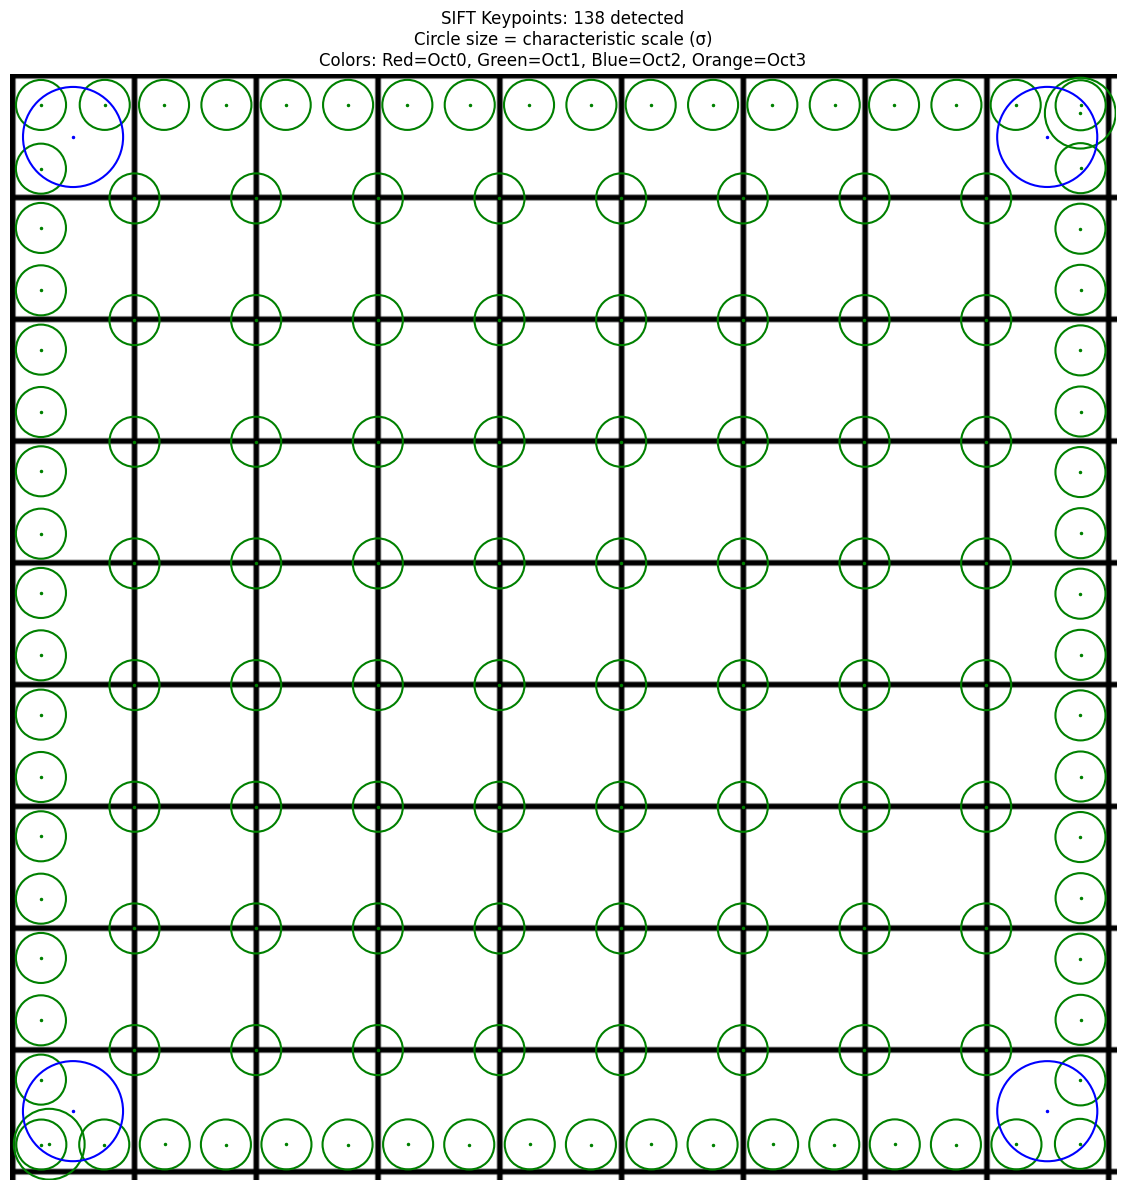

In [11]:
# Visualize final keypoints
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

ax.imshow(img, cmap='gray')

# Draw keypoints as circles with size proportional to sigma
for kp in keypoints:
    # Circle radius based on sigma
    radius = kp['sigma'] * 2
    
    # Color based on octave
    colors = ['red', 'green', 'blue', 'orange']
    color = colors[kp['octave'] % len(colors)]
    
    circle = plt.Circle((kp['x'], kp['y']), radius,
                         fill=False, color=color, linewidth=1.5)
    ax.add_patch(circle)
    
    # Small dot at center
    ax.plot(kp['x'], kp['y'], '.', color=color, markersize=3)

ax.set_title(f'SIFT Keypoints: {len(keypoints)} detected\n'
             f'Circle size = characteristic scale (σ)\n'
             f'Colors: Red=Oct0, Green=Oct1, Blue=Oct2, Orange=Oct3',
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Summary: What We've Learned

### Keypoint Localization Steps

1. **Find Extrema**: Detect points that are max/min in 3x3x3 neighborhood

2. **Sub-pixel Refinement**: 
   - Fit Taylor expansion to DoG
   - Solve for offset that maximizes/minimizes
   - Get sub-pixel accurate (x, y, σ)

3. **Low Contrast Filter**: 
   - Reject if |response| < 0.03
   - Removes noisy, unstable points

4. **Edge Response Filter**:
   - Check Hessian eigenvalue ratio
   - Keep corners (ratio < 10)
   - Reject edges (ratio ≥ 10)

### Why This Matters for Sudoku

After this filtering:
- Grid corners are kept (corner-like)
- Grid lines are rejected (edge-like)
- Noise is rejected (low contrast)

### Next Steps (Notebook 03)

Now we have **where** the keypoints are. Next we need:
- **Orientation assignment**: Make keypoints rotation-invariant
- Each keypoint gets a dominant orientation based on local gradients

In [12]:
print("Functions created in this notebook:")
print("  - compute_gradient_3d(dog_octave, scale, y, x)")
print("  - compute_hessian_3d(dog_octave, scale, y, x)")
print("  - localize_keypoint(dog_octave, scale, y, x)")
print("  - filter_low_contrast(keypoint, threshold)")
print("  - compute_hessian_2d(dog_image, y, x)")
print("  - filter_edge_response(dog_image, y, x, threshold)")
print("  - find_keypoints(dog_pyramid, sigmas, ...)")

Functions created in this notebook:
  - compute_gradient_3d(dog_octave, scale, y, x)
  - compute_hessian_3d(dog_octave, scale, y, x)
  - localize_keypoint(dog_octave, scale, y, x)
  - filter_low_contrast(keypoint, threshold)
  - compute_hessian_2d(dog_image, y, x)
  - filter_edge_response(dog_image, y, x, threshold)
  - find_keypoints(dog_pyramid, sigmas, ...)
